### Import libraries

In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load and study the dataset

In [134]:
df = pd.read_csv("airports.csv")
# source: https://ourairports.com/data/

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84897 entries, 0 to 84896
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 84897 non-null  int64  
 1   ident              84897 non-null  object 
 2   type               84897 non-null  object 
 3   name               84897 non-null  object 
 4   latitude_deg       84897 non-null  float64
 5   longitude_deg      84897 non-null  float64
 6   elevation_ft       70193 non-null  float64
 7   continent          45416 non-null  object 
 8   iso_country        84605 non-null  object 
 9   iso_region         84897 non-null  object 
 10  municipality       80138 non-null  object 
 11  scheduled_service  84897 non-null  object 
 12  icao_code          9812 non-null   object 
 13  iata_code          9063 non-null   object 
 14  gps_code           43989 non-null  object 
 15  local_code         35980 non-null  object 
 16  home_link          466

In [136]:
df.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [137]:
df.columns

Index(['id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg',
       'elevation_ft', 'continent', 'iso_country', 'iso_region',
       'municipality', 'scheduled_service', 'icao_code', 'iata_code',
       'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords'],
      dtype='object')

In [138]:
df.isnull().sum()

id                       0
ident                    0
type                     0
name                     0
latitude_deg             0
longitude_deg            0
elevation_ft         14704
continent            39481
iso_country            292
iso_region               0
municipality          4759
scheduled_service        0
icao_code            75085
iata_code            75834
gps_code             40908
local_code           48917
home_link            80236
wikipedia_link       68227
keywords             63838
dtype: int64

<Axes: >

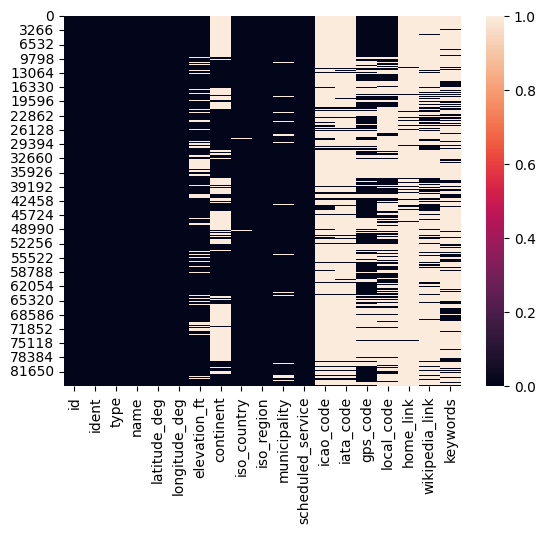

In [139]:
sns.heatmap(df.isnull())

### Drop unnecessary columns

In [140]:
cols_toDrop = ['elevation_ft', 'continent', 'municipality', 'scheduled_service', 'icao_code',
       'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords']

In [141]:
df_lessCols = df.copy()
df_lessCols.drop(labels = cols_toDrop, axis = 1, inplace = True)

### See null values

In [142]:
df_lessCols.isnull().sum()

id                   0
ident                0
type                 0
name                 0
latitude_deg         0
longitude_deg        0
iso_country        292
iso_region           0
iata_code        75834
dtype: int64

### Remove all airport types except for medium and large airports
Because most of them do not have iata code

In [143]:
df_lessCols.groupby(['type'])['id'].count()

type
balloonport          61
closed            13012
heliport          22726
large_airport      1194
medium_airport     4067
seaplane_base      1255
small_airport     42582
Name: id, dtype: int64

In [144]:
# Remove all the rows except for Large and Medium airports
rows_toExclude = ['heliport', 'balloonport', 'closed', 'seaplane_base', 'small_airport']
df_cleaned = df_lessCols[~df_lessCols['type'].isin(rows_toExclude)]
df_cleaned['type'].unique()

array(['medium_airport', 'large_airport'], dtype=object)

### Remove all rows without IATA code
Since airports without IATA codes are not used commercially, I'm removing all the airports with no IATA code

In [145]:
df_cleaned.isnull().sum()

id                 0
ident              0
type               0
name               0
latitude_deg       0
longitude_deg      0
iso_country       13
iso_region         0
iata_code        707
dtype: int64

In [146]:
# Take all the rows with IATA codes
df_cleaned = df_cleaned[df_cleaned['iata_code'].notnull()].copy()

In [147]:
df_cleaned.isnull().sum()

id                0
ident             0
type              0
name              0
latitude_deg      0
longitude_deg     0
iso_country      12
iso_region        0
iata_code         0
dtype: int64

<Axes: >

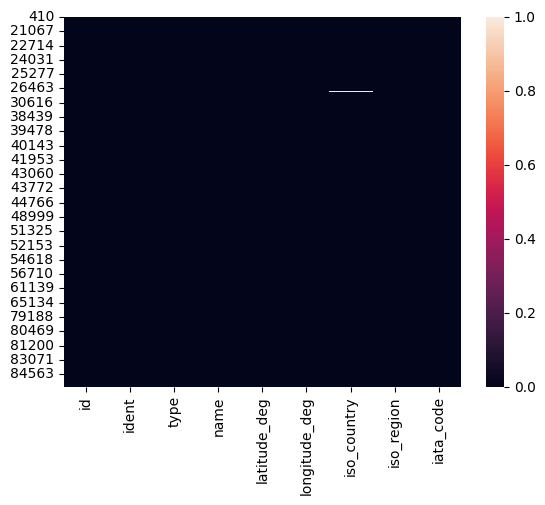

In [148]:
sns.heatmap(df_cleaned.isnull())

In [149]:
df_cleaned[df_cleaned['iso_country'].isnull()]

,id,ident,type,name,latitude_deg,longitude_deg,iso_country,iso_region,iata_code
28002,3024,FYAR,medium_airport,Arandis Airport,-22.461875,14.979322,NaN,NA-ER,ADI
28020,3026,FYGF,medium_airport,Grootfontein Airport,-19.602200,18.122700,NaN,NA-OD,GFY
28037,3027,FYKM,medium_airport,Katima Mulilo Airport,-17.634258,24.176688,NaN,NA-CA,MPA
28040,3028,FYKT,medium_airport,Keetmanshoop Airport,-26.539801,18.111401,NaN,NA-KA,KMP
28048,3029,FYLZ,medium_airport,Luderitz Airport,-26.687401,15.242900,NaN,NA-KA,LUD
28061,3031,FYOA,medium_airport,Ondangwa Airport,-17.878201,15.952600,NaN,NA-ON,OND
28063,3032,FYOG,medium_airport,Oranjemund Airport,-28.584700,16.446699,NaN,NA-KA,OMD
28076,3035,FYRU,medium_airport,Rundu Airport,-17.956499,19.719400,NaN,NA-KE,NDU
28089,3036,FYTM,medium_airport,Tsumeb Airport,-19.262079,17.732509,NaN,NA-OT,TSB
28092,3037,FYWB,large_airport,Walvis Bay International Airport,-22.979332,14.647102,NaN,NA-ER,WVB


In [150]:
# Missing country code "NA", which is Nambia

In [151]:
df_final = df_cleaned.fillna("NA")

In [152]:
df_final.isnull().sum()

id               0
ident            0
type             0
name             0
latitude_deg     0
longitude_deg    0
iso_country      0
iso_region       0
iata_code        0
dtype: int64

In [153]:
df_final.sort_values(by='id', inplace=True)
df_final = df_final.reset_index(drop=True)

### Merge ISO dataset to get country name
https://github.com/lukes/ISO-3166-Countries-with-Regional-Codes/blob/master/all/all.csv

In [154]:
iso = pd.read_csv("all.csv")

# Get necessary columns and rename them not to duplicate the columns with the same name
iso_need = iso[["name", "alpha-2"]].rename(columns={
    "alpha-2" : "iso_country",
    "name": "country_name"
})

iso_need.head(5)

,country_name,iso_country
0,Afghanistan,AF
1,Åland Islands,AX
2,Albania,AL
3,Algeria,DZ
4,American Samoa,AS


In [155]:
# Left Join - merge the new dataset based on the code
# column name has to be matched!!
df_enriched = pd.merge(
    df_final,
    iso_need,
    on="iso_country",
    how="left"
)

df_enriched.head(5)

,id,ident,type,name,latitude_deg,longitude_deg,iso_country,iso_region,iata_code,country_name
0,3,AGGH,large_airport,Honiara International Airport,-9.428000,160.054993,SB,SB-GU,HIR,Solomon Islands
1,4,AGGM,medium_airport,Munda Airport,-8.327970,157.263000,SB,SB-WE,MUA,Solomon Islands
2,8,ANYN,medium_airport,Nauru International Airport,-0.547893,166.919525,NR,NR-14,INU,Nauru
3,53,AYBK,medium_airport,Buka Airport,-5.422299,154.672698,PG,PG-NSB,BUA,Papua New Guinea
4,54,AYCH,medium_airport,Chimbu Airport,-6.024290,144.970993,PG,PG-CPK,CMU,Papua New Guinea


In [156]:
# reorder columns
new_order = [
    "id",
    "iata_code",
    "ident",
    "name",
    "type",
    "latitude_deg",
    "longitude_deg",
    "iso_country",
    "country_name",
    "iso_region"
]

# reorder the dataset
df_final = df_enriched[new_order]

df_final.head(5)

,id,iata_code,ident,name,type,latitude_deg,longitude_deg,iso_country,country_name,iso_region
0,3,HIR,AGGH,Honiara International Airport,large_airport,-9.428000,160.054993,SB,Solomon Islands,SB-GU
1,4,MUA,AGGM,Munda Airport,medium_airport,-8.327970,157.263000,SB,Solomon Islands,SB-WE
2,8,INU,ANYN,Nauru International Airport,medium_airport,-0.547893,166.919525,NR,Nauru,NR-14
3,53,BUA,AYBK,Buka Airport,medium_airport,-5.422299,154.672698,PG,Papua New Guinea,PG-NSB
4,54,CMU,AYCH,Chimbu Airport,medium_airport,-6.024290,144.970993,PG,Papua New Guinea,PG-CPK


In [157]:
# save the dataframe as a new csv file
# df_final.to_csv('airports_iata.csv', index=False, encoding='utf-8-sig')

### Merge region names

In [158]:
regions = pd.read_csv("regions.csv")
regions.head(5)


,id,code,local_code,name,continent,iso_country,wikipedia_link,keywords
0,302811,AD-02,02,Canillo Parish,EU,AD,https://en.wikipedia.org/wiki/Canillo,Airports in Canillo Parish
1,302812,AD-03,03,Encamp Parish,EU,AD,https://en.wikipedia.org/wiki/Encamp,Airports in Encamp Parish
2,302813,AD-04,04,La Massana Parish,EU,AD,https://en.wikipedia.org/wiki/La_Massana,Airports in La Massana Parish
3,302814,AD-05,05,Ordino Parish,EU,AD,https://en.wikipedia.org/wiki/Ordino,Airports in Ordino Parish
4,302815,AD-06,06,Sant Julià de Lòria Parish,EU,AD,https://en.wikipedia.org/wiki/Sant_Julià_de_Lòria,Airports in Sant Julià de Lòria Parish


In [159]:
regions_need = regions[["code", "name"]].rename(columns={
    "code" : "iso_region",
    "name": "region_name"
})

df_enriched = pd.merge(
    df_final,
    regions_need,
    on="iso_region",
    how="left"
)

df_enriched.head(5)

,id,iata_code,ident,name,type,latitude_deg,longitude_deg,iso_country,country_name,iso_region,region_name
0,3,HIR,AGGH,Honiara International Airport,large_airport,-9.428000,160.054993,SB,Solomon Islands,SB-GU,Guadalcanal Province
1,4,MUA,AGGM,Munda Airport,medium_airport,-8.327970,157.263000,SB,Solomon Islands,SB-WE,Western Province
2,8,INU,ANYN,Nauru International Airport,medium_airport,-0.547893,166.919525,NR,Nauru,NR-14,Yaren
3,53,BUA,AYBK,Buka Airport,medium_airport,-5.422299,154.672698,PG,Papua New Guinea,PG-NSB,Autonomous Region of Bougainville
4,54,CMU,AYCH,Chimbu Airport,medium_airport,-6.024290,144.970993,PG,Papua New Guinea,PG-CPK,Chimbu Province


In [160]:
df_enriched.isnull().sum()

id                0
iata_code         0
ident             0
name              0
type              0
latitude_deg      0
longitude_deg     0
iso_country       0
country_name     13
iso_region        0
region_name      16
dtype: int64

In [161]:
df_enriched[df_enriched["country_name"].isnull()]

,id,iata_code,ident,name,type,latitude_deg,longitude_deg,iso_country,country_name,iso_region,region_name
839,3024,ADI,FYAR,Arandis Airport,medium_airport,-22.461875,14.979322,NA,NaN,NA-ER,Erongo Region
840,3026,GFY,FYGF,Grootfontein Airport,medium_airport,-19.602200,18.122700,NA,NaN,NA-OD,Otjozondjupa Region
841,3027,MPA,FYKM,Katima Mulilo Airport,medium_airport,-17.634258,24.176688,NA,NaN,NA-CA,Zambezi Region
842,3028,KMP,FYKT,Keetmanshoop Airport,medium_airport,-26.539801,18.111401,NA,NaN,NA-KA,ǁKaras Region
843,3029,LUD,FYLZ,Luderitz Airport,medium_airport,-26.687401,15.242900,NA,NaN,NA-KA,ǁKaras Region
844,3031,OND,FYOA,Ondangwa Airport,medium_airport,-17.878201,15.952600,NA,NaN,NA-ON,Oshana Region
845,3032,OMD,FYOG,Oranjemund Airport,medium_airport,-28.584700,16.446699,NA,NaN,NA-KA,ǁKaras Region
846,3035,NDU,FYRU,Rundu Airport,medium_airport,-17.956499,19.719400,NA,NaN,NA-KE,Kavango East Region
847,3036,TSB,FYTM,Tsumeb Airport,medium_airport,-19.262079,17.732509,NA,NaN,NA-OT,Oshikoto Region
848,3037,WVB,FYWB,Walvis Bay International Airport,large_airport,-22.979332,14.647102,NA,NaN,NA-ER,Erongo Region


In [164]:
df_enriched[df_enriched["region_name"].isnull()]
# iso[iso["alpha-2"] == "KE"]

,id,iata_code,ident,name,type,latitude_deg,longitude_deg,iso_country,country_name,iso_region,region_name
961,3205,EDL,HKEL,Eldoret International Airport,large_airport,0.404458,35.238899,KE,Kenya,KE-700,NaN
962,3206,NBO,HKJK,Jomo Kenyatta International Airport,large_airport,-1.318886,36.928233,KE,Kenya,KE-110,NaN
963,3208,KIS,HKKI,Kisumu International Airport,large_airport,-0.086139,34.728901,KE,Kenya,KE-600,NaN
964,3209,KTL,HKKT,Kitale Airport,medium_airport,0.971989,34.958599,KE,Kenya,KE-700,NaN
965,3210,LKG,HKLK,Lokichogio Airport,medium_airport,4.204120,34.348202,KE,Kenya,KE-700,NaN
966,3211,LOK,HKLO,Lodwar Airport,medium_airport,3.121970,35.608700,KE,Kenya,KE-700,NaN
967,3212,LAU,HKLU,Manda Airport,medium_airport,-2.252431,40.912892,KE,Kenya,KE-300,NaN
968,3213,MBA,HKMO,Moi International Airport,large_airport,-4.034830,39.594200,KE,Kenya,KE-300,NaN
969,3215,WIL,HKNW,Nairobi Wilson Airport,medium_airport,-1.321720,36.814800,KE,Kenya,KE-110,NaN
970,3217,WJR,HKWJ,Wajir Airport,medium_airport,1.733240,40.091599,KE,Kenya,KE-500,NaN


In [172]:
df_enriched.iloc[1915]["country_name"] = "Kosovo"
df_enriched["country_name"].fillna("Namibia", inplace=True)
df_enriched["region_name"].fillna("N/A", inplace=True)

/var/folders/ls/lrhw03tn2ssbykttbp1n2ns80000gn/T/ipykernel_89547/3811318574.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enriched.iloc[1915]["country_name"] = "Kosovo"
/var/folders/ls/lrhw03tn2ssbykttbp1n2ns80000gn/T/ipykernel_89547/3811318574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_enriched["country_name"].fillna("Nam

In [173]:
df_enriched[df_enriched["region_name"].isnull()]

,id,iata_code,ident,name,type,latitude_deg,longitude_deg,iso_country,country_name,iso_region,region_name


In [174]:
df_enriched.to_csv('airports_iata.csv', index=False, encoding='utf-8-sig')